In [1]:
import cv2
import matplotlib.pyplot as plt
from google.colab import files
import numpy as np

In [2]:
uploaded = files.upload("C:/Users/23108113/Desktop/desktop_358.png")

Saving desktop_358.png to C:/Users/23108113/Desktop/desktop_358.png/desktop_358.png


In [3]:
img_path = next(iter(uploaded))
img = cv2.imread(img_path)

In [5]:
if img is None:
  print("Error: Image not found or unable to read.")

In [6]:
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

In [7]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

In [8]:
resized = cv2.resize(img, (300, 300))

In [9]:
resized_rgb = cv2.cvtColor(resized, cv2.COLOR_BGR2RGB)

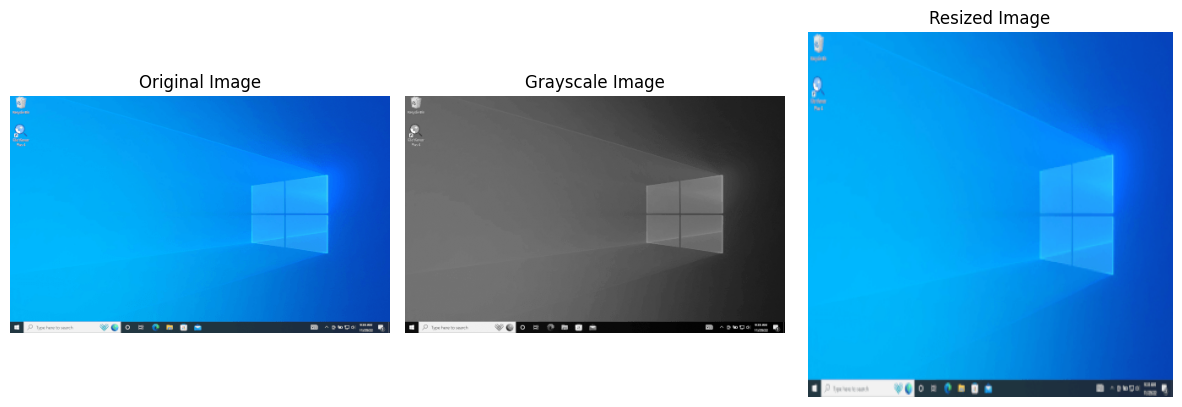

In [10]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.title("Original Image")
plt.imshow(img_rgb)
plt.axis('off')
plt.subplot(1, 3, 2)
plt.title("Grayscale Image")
plt.imshow(gray, cmap='gray')
plt.axis('off')
plt.subplot(1, 3, 3)
plt.title("Resized Image")
plt.imshow(resized_rgb)
plt.axis('off')
plt.tight_layout()
plt.show()

In [11]:
cv2.imwrite('gray_sample.jpg', gray)
cv2.imwrite('resized_sample.jpg', resized)
True


True

In [12]:
print("Images saved as 'gray_sample.jpg' and 'resized_sample.jpg'")

Images saved as 'gray_sample.jpg' and 'resized_sample.jpg'


Saving desktop_358.png to desktop_358.png


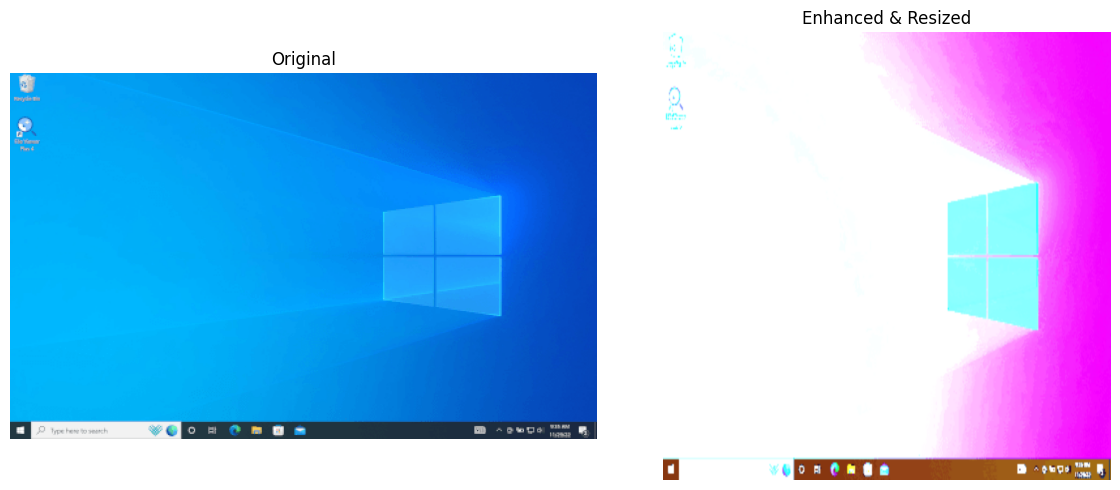

In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

uploaded = files.upload()
img_path = next(iter(uploaded))
img = cv2.imread(img_path)

15
def auto_brightness_contrast(image, clip_hist_percent=25):
  gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
  hist = cv2.calcHist([gray],[0],None,[256],[0,256]).flatten()
  acc = np.cumsum(hist)
  clip = clip_hist_percent * (acc[-1] / 100.0) / 2.0
  min_gray = np.searchsorted(acc, clip)
  max_gray = np.searchsorted(acc, acc[-1] - clip)
  alpha = 255 / (max_gray - min_gray + 1e-5)
  beta = -min_gray * alpha
  return cv2.convertScaleAbs(image, alpha=alpha, beta=beta)
enhanced = auto_brightness_contrast(img)
resized = cv2.resize(enhanced, (1080, 1080))

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
ax[0].set_title("Original")
ax[1].imshow(cv2.cvtColor(resized, cv2.COLOR_BGR2RGB))
ax[1].set_title("Enhanced & Resized")
for a in ax: a.axis('off')
plt.tight_layout()
plt.show()



In [16]:
!pip install opencv-python-headless --quiet

import cv2
from google.colab import files
import os

print("Upload your CCTV image (e.g., .jpg, .png)...")
uploaded = files.upload()

input_image_path = list(uploaded.keys())[0]

color_image = cv2.imread(input_image_path)

if color_image is None:
  print("Error: Unable to read the image.")
else:

  gray_image = cv2.cvtColor(color_image, cv2.COLOR_BGR2GRAY)

  output_image_path = 'cam_001_gray.jpg'
  cv2.imwrite(output_image_path, gray_image)

  print(f"Grayscale image saved as: {output_image_path}")
  files.download(output_image_path)

Upload your CCTV image (e.g., .jpg, .png)...


Saving images.jpg to images (1).jpg
Grayscale image saved as: cam_001_gray.jpg


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saving desktop_358.png to desktop_358 (1).png
Saving images.jpg to images (4).jpg
MSE: 100.05
SSIM: 0.4759


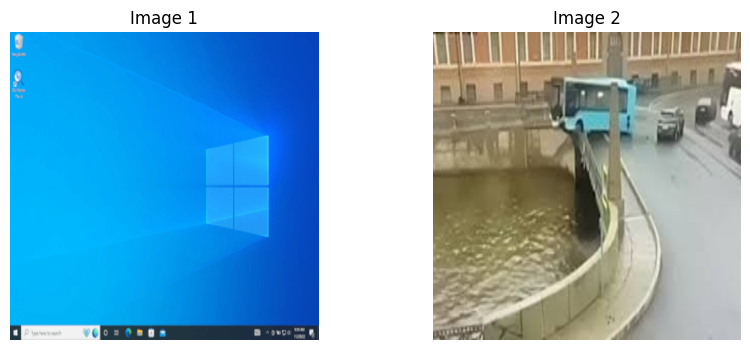

In [21]:
import cv2
import numpy as np
from google.colab import files
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim

uploaded = files.upload()

paths = list(uploaded.keys())

img1 = cv2.imread(paths[0])
img2 = cv2.imread(paths[1])
img1 = cv2.resize(img1, (500, 500))
img2 = cv2.resize(img2, (500, 500))
gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

mse = np.mean((gray1 - gray2) ** 2)
ssim_score, _ = ssim(gray1, gray2, full=True)
print(f"MSE: {mse:.2f}")
print(f"SSIM: {ssim_score:.4f}")

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(cv2.cvtColor(img1, cv2.COLOR_BGR2RGB))
ax[0].set_title("Image 1")
ax[1].imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))
ax[1].set_title("Image 2")
for a in ax: a.axis('off')
plt.show()


Upload an image to detect red objects...


Saving images.jpg to images (5).jpg


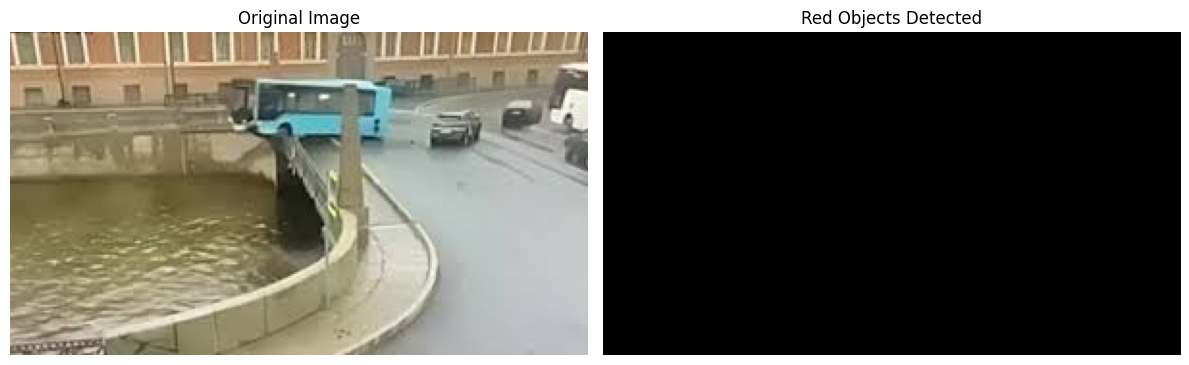

In [22]:
# Step 1: Install OpenCV (only needed in Colab)
!pip install opencv-python-headless --quiet
# Step 2: Import required libraries
import cv2
import numpy as np
from google.colab import files
from matplotlib import pyplot as plt
# Step 3: Upload an image
print("Upload an image to detect red objects...")
uploaded = files.upload()
input_image_path = list(uploaded.keys())[0]
# Step 4: Read the image
image = cv2.imread(input_image_path)
if image is None:
  print("Error: Couldn't read the image.")
else:
# Step 5: Convert BGR image to HSV color space
  hsv_image = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
# Step 6: Define range for red color in HSV
# Red appears in two ranges in HSV (around 0° and 180°)
  lower_red1 = np.array([0, 120, 70])
  upper_red1 = np.array([10, 255, 255])
  lower_red2 = np.array([170, 120, 70])
  upper_red2 = np.array([180, 255, 255])
# Step 7: Create masks for red color
  mask1 = cv2.inRange(hsv_image, lower_red1, upper_red1)
  mask2 = cv2.inRange(hsv_image, lower_red2, upper_red2)
  red_mask = mask1 + mask2

  red_detected = cv2.bitwise_and(image, image, mask=red_mask)
# Step 9: Show original and result side by side
  plt.figure(figsize=(12, 6))
  plt.subplot(1, 2, 1)
  plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
  plt.title("Original Image")
  plt.axis('off')
  plt.subplot(1, 2, 2)
  plt.imshow(cv2.cvtColor(red_detected, cv2.COLOR_BGR2RGB))
  plt.title("Red Objects Detected")
  plt.axis('off')
  plt.tight_layout()
  plt.show()



Upload your dashcam image:


Saving images.jpg to images (7).jpg
Skipping ROI (100, 200, 150, 50) because it's outside the image boundaries.
Skipping ROI (400, 180, 160, 55) because it's outside the image boundaries.


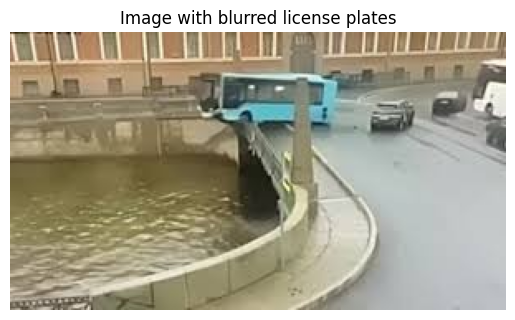

In [24]:
import cv2
from google.colab import files
import matplotlib.pyplot as plt

print("Upload your dashcam image:")
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

image = cv2.imread(image_path)

# Check if the image was loaded successfully
if image is None:
    print(f"Error: Could not read image from {image_path}. Please make sure the file exists and is a valid image.")
else:
    license_plate_rois = [
        (100, 200, 150, 50), # Example ROI
        (400, 180, 160, 55)  # Example ROI
    ]
    height, width = image.shape[:2]

    # Iterate through the ROIs and apply blur if they are within image boundaries
    for (x, y, w, h) in license_plate_rois:
        # Make sure ROI is inside image bounds
        if x < 0 or y < 0 or x + w > width or y + h > height:
            print(f"Skipping ROI {(x, y, w, h)} because it's outside the image boundaries.")
            continue # Skip to the next ROI if this one is out of bounds

        # These lines will only execute if the ROI is within bounds
        roi = image[y:y+h, x:x+w]
        blurred_roi = cv2.GaussianBlur(roi, (51, 51), 0)
        image[y:y+h, x:x+w] = blurred_roi

    # Display the result after processing all valid ROIs
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title("Image with blurred license plates")
    plt.axis('off')
    plt.show()




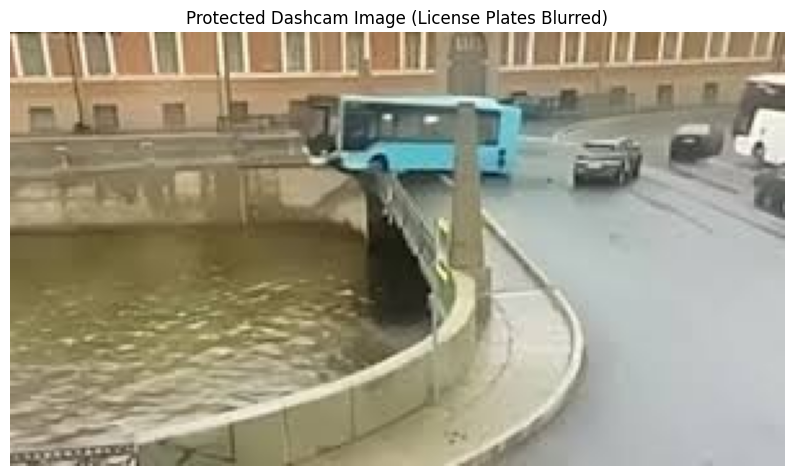

Saved protected image as protected_dashcam.jpg


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [25]:
plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Protected Dashcam Image (License Plates Blurred)")
plt.axis('off')
plt.show()
# Step 6: Save and download the protected image
output_filename = "protected_dashcam.jpg"
cv2.imwrite(output_filename, image)
print(f"Saved protected image as {output_filename}")
files.download(output_filename)
